# Free Choice 2

# Imports and Data Loading

Imports

In [1]:
# imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Data Loading

In [2]:
exercise_1_data = np.loadtxt("../data/session1/ex1_trial_2/theta.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
exercise_2_data_180 = np.loadtxt("../data/session1/ex2_trial_2/180/theta.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
exercise_2_data_360 = np.loadtxt("../data/session1/ex2_trial_2/360/theta.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated

exercise_1_cossq_data = np.loadtxt("../data/session1/ex1_trial_2/cosinesquaredtheta.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated

# Malus' Law

# exercise 1

ex1_position = exercise_1_data[0] # Sensor Position (Radians)
ex1_intensity = exercise_1_data[1] # Light Intensity (Volts)

# exercise 2

ex2_position_180 = exercise_2_data_180[0] # Sensor Position (Radians)
ex2_intensity_180 = exercise_2_data_180[1] # Light Intensity (Volts)

ex2_position_360 = exercise_2_data_360[0] # Sensor Position (Radians)
ex2_intensity_360 = exercise_2_data_360[1] # Light Intensity (Volts)

ex2_position_combined = np.concatenate((ex2_position_180, ex2_position_360 + np.pi), axis=0)
ex2_intensity_combined = np.concatenate((ex2_intensity_180, ex2_intensity_360), axis=0)

# Brewster

# exercise 3

exercise_3_data_no_polarizer = np.loadtxt("../data/clean_data/no_polarizer.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
no_polarizer_position = exercise_3_data_no_polarizer[0] - 85 # actually starts at 95. This is wrt the rotational measuring thing
no_polarizer_intensity = exercise_3_data_no_polarizer[1]

exercise_3_data_horizontal = np.loadtxt("../data/clean_data/horizontal.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
horizontal_position =  exercise_3_data_horizontal[0] - 85 # actually starts at 95
horizontal_intensity = exercise_3_data_horizontal[1]

exercise_3_data_vertical = np.loadtxt("../data/clean_data/vertical.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
vertical_position = exercise_3_data_vertical[0] - 85 # actually starts at 95
vertical_intensity = exercise_3_data_vertical[1]


# Uncertainties

In [3]:
# there is a big assumption that the uncertainty of the sensor does not depend on intensity.

malus_1_uncertainty = np.loadtxt("../data/session3/unc/malus1.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
brewster_1_uncertainty = np.loadtxt("../data/session3/unc/brewster1.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated
brewster_10_uncertainty = np.loadtxt("../data/session3/unc/brewster10.txt", delimiter='\t', comments='#', unpack=True, skiprows=2) # tab separated

In [4]:
print(f"malus sensor 1 gain:\nmean: {np.mean(malus_1_uncertainty[1])}\nuncertainty: {np.std(malus_1_uncertainty[1])}")
print(f"brewster sensor 1 gain:\nmean: {np.mean(brewster_1_uncertainty[1])}\nuncertainty: {np.std(brewster_1_uncertainty[1])}")
print(f"brewster sensor 10 gain:\nmean: {np.mean(brewster_10_uncertainty[1])}\nuncertainty: {np.std(brewster_10_uncertainty[1])}")

malus sensor 1 gain:
mean: 1.2314533604777416
uncertainty: 0.010426601916429589
brewster sensor 1 gain:
mean: 1.218340076775432
uncertainty: 0.0033007650473998004
brewster sensor 10 gain:
mean: 1.2373230562827224
uncertainty: 0.002754706969711812


# Model Functions

In [5]:
# function for calculating chi squared reduced.
def chi_squared_reduced(y_measure, y_predict, errors, number_of_parameters):
    """Calculates the reduced chi squared of data, prediction and errors."""
    return (np.sum(((y_measure - y_predict) ** 2 )/ (errors ** 2)))/(y_measure.size - number_of_parameters)

## Malus

In [6]:
# fit raw data to cos^2 theta

def cossqtheta(theta, a, b, c):
    return a * (np.cos(b * (theta - c)) ** 2)

In [7]:
def coscos(theta, a, b, c, d):
    return a * (np.cos(b * (theta - c)) ** 2) * (np.cos(b * ((d - theta) - c)) ** 2)

## Brewster

In [8]:
# Snell and Reflectance equations combined.

def perpendicular_reflectance(theta_in, n_2, a, b, c):
    theta_i = theta_in + b # shift 
    n_1 = 1 # by assumptions in lab manual
    theta_f = np.arcsin((n_1/n_2) * np.sin(theta_i))

    # formula to curve fit.
    return (((n_1 * theta_i - (n_2 * np.cos(theta_f))) / (n_1 * theta_i + (n_2 * np.cos(theta_f)))) ** 2) * c + a  # amplitude is c, shift is a

In [9]:
def parallel_reflectance(theta_in, n_2, a, b, c):
    theta_i = theta_in + b # shift 
    n_1 = 1 # by assumptions in lab manual
    theta_f = np.arcsin((n_1/n_2) * np.sin(theta_i))

    # formula to curve fit.
    return (((n_1 * np.cos(theta_f) - (n_2 * theta_i)) / (n_1 * np.cos(theta_f) + (n_2 * theta_i))) ** 2) * c + a # amplitude is c, shift is a

In [10]:
def all_reflectance(theta_in, n_2, a, b, c):
    return (parallel_reflectance(theta_in, n_2, a, b, c) + perpendicular_reflectance(theta_in, n_2, a, b, c)) / 2

# Curve Fit and Model Parameters

## Malus

In [11]:
# ex1 2 polarizers
popt, pcov = curve_fit(cossqtheta, xdata=ex1_position, ydata=ex1_intensity, absolute_sigma=True, sigma=0.01) #, absolute_sigma=True, sigma = propTimeError)
pstd = np.sqrt(np.diag(pcov))

# ex2 3 polarizers
popt2, pcov2 = curve_fit(coscos, xdata=ex2_position_combined, ydata=ex2_intensity_combined, absolute_sigma=True, sigma=0.01)
pstd2 = np.sqrt(np.diag(pcov2))

# ex1
print("chi squared reduced of 2 polarizers =",chi_squared_reduced(ex1_intensity, cossqtheta(ex1_position, popt[0], popt[1], popt[2]), 1, len(popt)))
print(f"Value of a: {popt[0]} \nValue of b: {popt[1]} \nValue of c: {popt[2]}")
print(f"Uncertainty in a: {pstd[0]} \nUncertainty in b: {pstd[1]} \nUncertainty in c: {pstd[2]}")
print("_________________________________________________________")
# ex2
print("chi squared reduced of 3 polarizers =",chi_squared_reduced(ex2_position_combined, coscos(ex2_intensity_combined, popt2[0], popt2[1], popt2[2], popt2[3]), 1, len(popt2)))
print(f"Value of a: {popt2[0]} \nValue of b: {popt2[1]} \nValue of c: {popt2[2]} \nValue of d: {popt2[3]}")
print(f"Uncertainty in a: {pstd2[0]} \nUncertainty in b: {pstd2[1]} \nUncertainty in c: {pstd2[2]} \nUncertainty in d: {pstd2[3]}")


chi squared reduced of 2 polarizers = 0.0016490399732635114
Value of a: 4.499491008289387 
Value of b: 1.0061932109053942 
Value of c: 0.5753631935406328
Uncertainty in a: 0.0006219366691890683 
Uncertainty in b: 0.00012001051358845225 
Uncertainty in c: 0.00015626329197983388
_________________________________________________________
chi squared reduced of 3 polarizers = 9.890910821959395
Value of a: 5.0746276846373375 
Value of b: 0.9925153046850576 
Value of c: 0.5273667685931266 
Value of d: -0.2507116881884684
Uncertainty in a: 0.0029608314948976837 
Uncertainty in b: 0.00010934463392909071 
Uncertainty in c: 0.00042683652302864924 
Uncertainty in d: 0.0008366070083360444


## Brewster

In [12]:
# curve fit horizontal
popt_h, pcov_h = curve_fit(perpendicular_reflectance, xdata=horizontal_position, ydata=horizontal_intensity, absolute_sigma=True, sigma=0.003, maxfev=10000) 
pstd_h = np.sqrt(np.diag(pcov_h))

# vertical
popt_v, pcov_v = curve_fit(parallel_reflectance, xdata=vertical_position, ydata=vertical_intensity, absolute_sigma=True, sigma=0.003) 
pstd_v = np.sqrt(np.diag(pcov_v))

# none
popt_n, pcov_n = curve_fit(all_reflectance, xdata=no_polarizer_position, ydata=no_polarizer_intensity, absolute_sigma=True, sigma=0.003) 
pstd_n = np.sqrt(np.diag(pcov_n))


print("chi squared reduced of horizontal =",chi_squared_reduced(horizontal_intensity, perpendicular_reflectance(horizontal_position, popt_h[0], popt_h[1], popt_h[2], popt_h[3]), 1, len(popt_h)))
print(f"Value of n_2: {popt_h[0]} \nValue of a: {popt_h[1]} \nValue of b: {popt_h[2]} \nValue of c: {popt_h[3]}")
print(f"Uncertainty in n_2: {pstd_h[0]} \nUncertainty in a: {pstd_h[1]} \nUncertainty in b: {pstd_h[2]} \nUncertainty in c: {pstd_h[3]}")
print("_________________________________________________________")
print("chi squared reduced of vertical =",chi_squared_reduced(vertical_intensity, parallel_reflectance(vertical_position, popt_v[0], popt_v[1], popt_v[2], popt_v[3]), 1, len(popt_v)))
print(f"Value of n_2: {popt_v[0]} \nValue of a: {popt_v[1]} \nValue of b: {popt_v[2]} \nValue of c: {popt_v[3]}")
print(f"Uncertainty in n_2: {pstd_v[0]} \nUncertainty in a: {pstd_v[1]} \nUncertainty in b: {pstd_v[2]} \nUncertainty in c: {pstd_v[3]}")
print("_________________________________________________________")
print("chi squared reduced of none =",chi_squared_reduced(no_polarizer_intensity, all_reflectance(no_polarizer_position, popt_n[0], popt_n[1], popt_n[2], popt_n[3]), 1, len(popt_n)))
print(f"Value of n_2: {popt_n[0]} \nValue of a: {popt_n[1]} \nValue of b: {popt_n[2]} \nValue of c: {popt_n[3]}")
print(f"Uncertainty in n_2: {pstd_n[0]} \nUncertainty in a: {pstd_n[1]} \nUncertainty in b: {pstd_n[2]} \nUncertainty in c: {pstd_n[3]}")

chi squared reduced of horizontal = 0.00536869864070037
Value of n_2: 31.683837929897763 
Value of a: 0.07001390817481476 
Value of b: -36.558699141489235 
Value of c: 37.54100340904807
Uncertainty in n_2: 0.012598295504611097 
Uncertainty in a: 0.00018314204610450627 
Uncertainty in b: 0.011256274585139352 
Uncertainty in c: 0.026169384042817764
_________________________________________________________
chi squared reduced of vertical = 0.4251171827693606
Value of n_2: 0.9999986943541054 
Value of a: 0.49113434539786294 
Value of b: 1.612974958360588 
Value of c: 0.4122284776167357
Uncertainty in n_2: 1.4139533194646505e-05 
Uncertainty in a: 0.0015748616962502641 
Uncertainty in b: 0.002235090379890384 
Uncertainty in c: 0.0016698847783698663
_________________________________________________________
chi squared reduced of none = 0.8137598605795068
Value of n_2: 0.9999924697628563 
Value of a: 0.6748943004819753 
Value of b: 0.465686331820694 
Value of c: 0.6240877008680114
Uncertainty

/var/folders/b4/87nbcb5j6d772d537gj3mnc80000gn/T/ipykernel_72228/1316014866.py:4: RuntimeWarning: invalid value encountered in arcsin
  theta_f = np.arcsin((n_1/n_2) * np.sin(theta_i))
/var/folders/b4/87nbcb5j6d772d537gj3mnc80000gn/T/ipykernel_72228/1250819704.py:6: RuntimeWarning: invalid value encountered in arcsin
  theta_f = np.arcsin((n_1/n_2) * np.sin(theta_i))


# Graphs for Curve Fit

## Malus

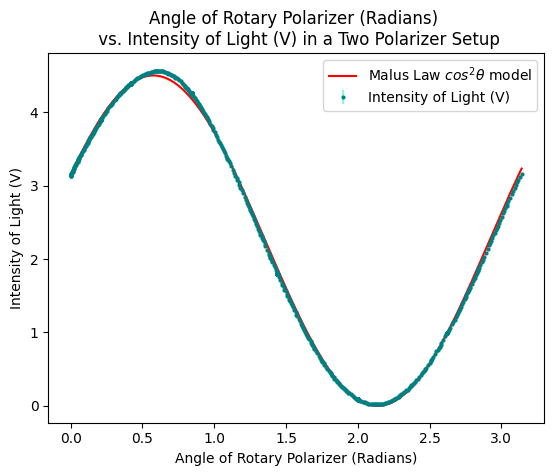

In [13]:
# scatter error bar
plt.errorbar(x = ex1_position, y = ex1_intensity, yerr=0.01, fmt= 'o',
            ms=2, color='teal', ecolor='aquamarine', label="Intensity of Light (V)")

# curve fit plot
plt.plot(ex1_position, cossqtheta(ex1_position, popt[0], popt[1], popt[2]), label = "Malus Law $cos^2\\theta$ model", color='red')

# plt.plot(ex1_position, np.cos(ex1_position - 0.58) ** 2 * 4.5, label = "Malus Law $cos^2\\theta$ model", color='blue') # actual malus law

# Legend and titles
plt.legend()
plt.xlabel("Angle of Rotary Polarizer (Radians)")
plt.ylabel("Intensity of Light (V)")
plt.title("Angle of Rotary Polarizer (Radians) \n vs. Intensity of Light (V) in a Two Polarizer Setup")

plt.show()

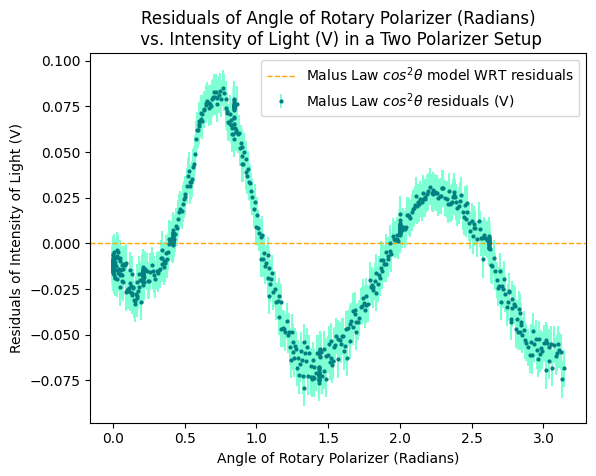

In [14]:
residuals = ex1_intensity - cossqtheta(ex1_position, popt[0], popt[1], popt[2])

plt.errorbar(x = ex1_position, y = residuals, yerr = 0.01, fmt= 'o', ms=2, label="Malus Law $cos^2\\theta$ residuals (V)",ls='', color='teal', ecolor='aquamarine')
plt.axhline(y=0, color='orange', linestyle='--', linewidth=1, label="Malus Law $cos^2\\theta$ model WRT residuals") 

# legend and titles
plt.legend()
plt.xlabel("Angle of Rotary Polarizer (Radians)")
plt.ylabel("Residuals of Intensity of Light (V)")
plt.title("Residuals of Angle of Rotary Polarizer (Radians)\n vs. Intensity of Light (V) in a Two Polarizer Setup")

plt.show()

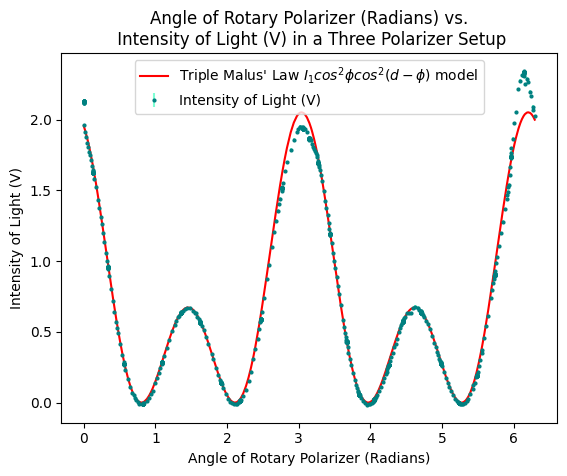

In [15]:
# scatter error bar
plt.errorbar(x = ex2_position_combined, y = ex2_intensity_combined, yerr=0.01, fmt= 'o',
            ms=2, color='teal', ecolor='aquamarine', label="Intensity of Light (V)")

# curve fit plot
plt.plot(ex2_position_combined, coscos(ex2_position_combined, popt2[0], popt2[1], popt2[2], popt2[3]), label = "Triple Malus' Law $I_1cos^2\\phi cos^2(d - \phi)$ model", color='red')

# Legend and titles
plt.legend()
plt.xlabel("Angle of Rotary Polarizer (Radians)")
plt.ylabel("Intensity of Light (V)")
plt.title("Angle of Rotary Polarizer (Radians) vs.\n Intensity of Light (V) in a Three Polarizer Setup")

plt.show()

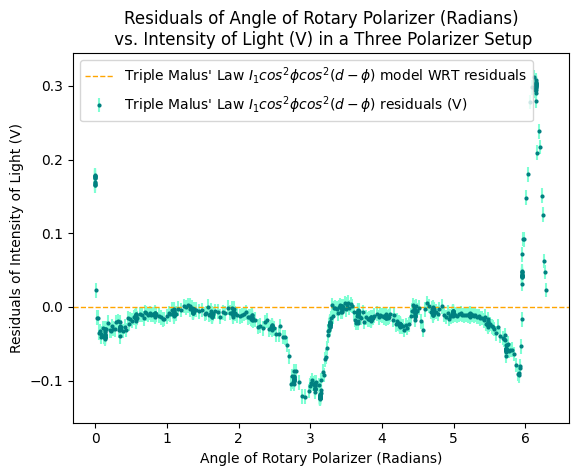

In [16]:
residuals = ex2_intensity_combined - coscos(ex2_position_combined, popt2[0], popt2[1], popt2[2], popt2[3])

plt.errorbar(x = ex2_position_combined, y = residuals, yerr = 0.01, fmt= 'o', ms=2, label="Triple Malus' Law $I_1cos^2\\phi cos^2(d - \phi)$ residuals (V)",ls='', color='teal', ecolor='aquamarine')
plt.axhline(y=0, color='orange', linestyle='--', linewidth=1, label="Triple Malus' Law $I_1cos^2\\phi cos^2(d - \phi)$ model WRT residuals") 

# legend and titles
plt.legend()
plt.xlabel("Angle of Rotary Polarizer (Radians)")
plt.ylabel("Residuals of Intensity of Light (V)")
plt.title("Residuals of Angle of Rotary Polarizer (Radians)\n vs. Intensity of Light (V) in a Three Polarizer Setup")

plt.show() # notice the spike at the end

## Brewster

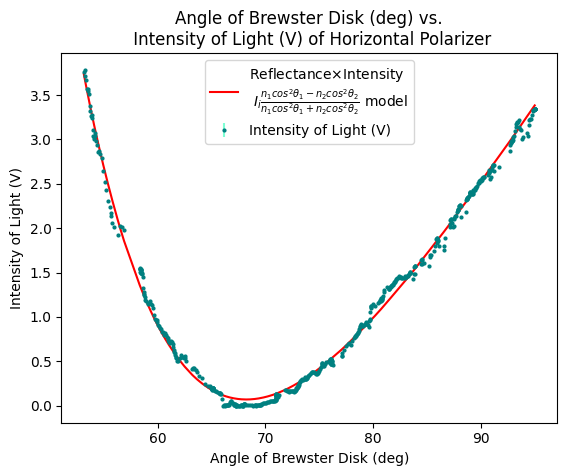

In [17]:
# scatter error bar
plt.errorbar(x = horizontal_position, y = horizontal_intensity, yerr = 0.003, fmt= 'o',
            ms=2, color='teal', ecolor='aquamarine', label="Intensity of Light (V)")

plt.plot(horizontal_position, perpendicular_reflectance(horizontal_position, popt_h[0], popt_h[1], popt_h[2], popt_h[3]), label = "Reflectance$\\times$Intensity \n $I_i\\frac{n_1cos^2\\theta_1 - n_2cos^2\\theta_2}{n_1cos^2\\theta_1 + n_2cos^2\\theta_2}$ model", color='red')


# Legend and titles
plt.legend()
plt.xlabel("Angle of Brewster Disk (deg)")
plt.ylabel("Intensity of Light (V)")
plt.title("Angle of Brewster Disk (deg) vs.\n Intensity of Light (V) of Horizontal Polarizer")

plt.show()

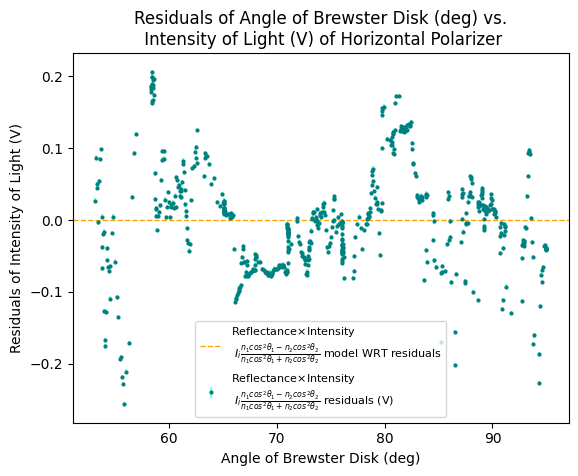

In [18]:
residuals = horizontal_intensity - perpendicular_reflectance(horizontal_position, popt_h[0], popt_h[1], popt_h[2], popt_h[3])

plt.errorbar(x = horizontal_position, y = residuals, yerr = 0.003, fmt= 'o', ms=2, label="Reflectance$\\times$Intensity \n $I_i\\frac{n_1cos^2\\theta_1 - n_2cos^2\\theta_2}{n_1cos^2\\theta_1 + n_2cos^2\\theta_2}$ residuals (V)",ls='', color='teal', ecolor='aquamarine')
plt.axhline(y=0, color='orange', linestyle='--', linewidth=1, label="Reflectance$\\times$Intensity \n $I_i\\frac{n_1cos^2\\theta_1 - n_2cos^2\\theta_2}{n_1cos^2\\theta_1 + n_2cos^2\\theta_2}$ model WRT residuals") 

# legend and titles
plt.legend(fontsize=8)
plt.xlabel("Angle of Brewster Disk (deg)")
plt.ylabel("Residuals of Intensity of Light (V)")
plt.title("Residuals of Angle of Brewster Disk (deg) vs.\n Intensity of Light (V) of Horizontal Polarizer")

plt.show() # notice the spike at the end

Brewster found at 68 deg. Uncertainty of 1 deg.

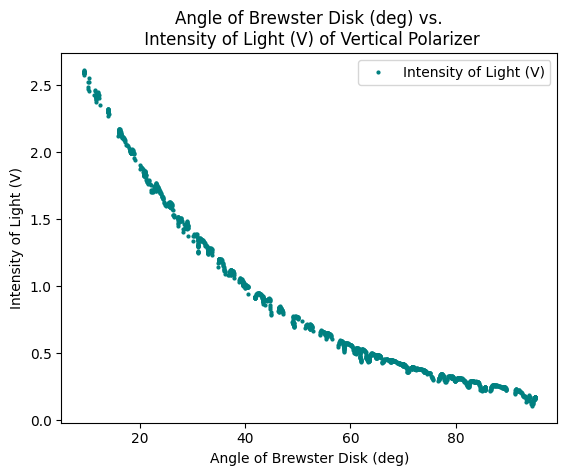

In [19]:
plt.errorbar(x = vertical_position, y = vertical_intensity, fmt= 'o',
            ms=2, color='teal', ecolor='aquamarine', label="Intensity of Light (V)")

# plt.plot(vertical_position, parallel_reflectance(vertical_position, popt_v[0], popt_v[1], popt_v[2], popt_v[3]), label = "Triple Malus Law $cos^2\\phi cos^2(a-\\phi)$ model", color='red')


# Legend and titles
plt.legend()
plt.xlabel("Angle of Brewster Disk (deg)") 
plt.ylabel("Intensity of Light (V)")
plt.title("Angle of Brewster Disk (deg) vs.\n Intensity of Light (V) of Vertical Polarizer")

plt.show()

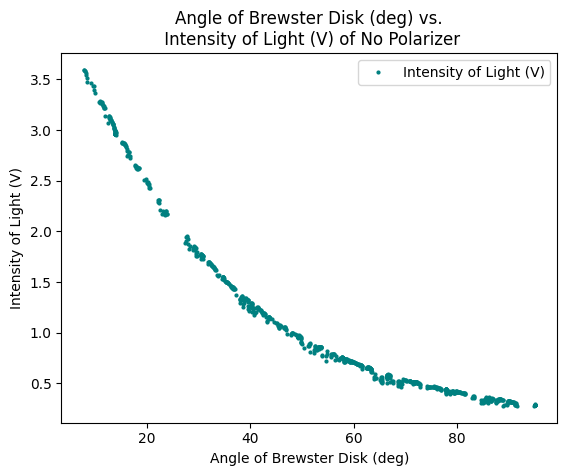

In [20]:
plt.errorbar(x = no_polarizer_position, y = no_polarizer_intensity, fmt= 'o',
            ms=2, color='teal', ecolor='aquamarine', label="Intensity of Light (V)")

# plt.plot(no_polarizer_position, all_reflectance(no_polarizer_position, popt_n[0], popt_n[1], popt_n[2], popt_n[3]), label = "Triple Malus Law $cos^2\\phi cos^2(a-\\phi)$ model", color='red')

# Legend and titles
plt.legend()
plt.xlabel("Angle of Brewster Disk (deg)")
plt.ylabel("Intensity of Light (V)")
plt.title("Angle of Brewster Disk (deg) vs.\n Intensity of Light (V) of No Polarizer")

plt.show()